## 4 - Scatter Plots

### What is a Scatter Plot?
A **scatter plot** places each data point as a dot at its `(x, y)` coordinate. It is the best chart for exploring **relationships and correlations** between two numeric variables.

### When to use a Scatter Plot
✅ Is there a relationship between study hours and scores?
✅ Do students who attend more score higher?
✅ Identifying clusters or outliers
❌ Not useful for categories (use bar chart)

### Reading a Scatter Plot
```
Points going up-right   → Positive correlation (both increase together)
Points going down-right → Negative correlation (one increases, other decreases)
Points spread randomly  → No correlation
Points very tight       → Strong correlation
Points very spread      → Weak correlation
```

### Key `plt.scatter()` parameters
| Parameter | What it does |
|-----------|-------------|
| `x`, `y` | Coordinates |
| `c` | Colour — single value OR array (encodes a 3rd variable) |
| `s` | Size — single value OR array (bubble chart = 3rd variable) |
| `cmap` | Colormap name when `c` is a numeric array |
| `alpha` | Transparency |
| `edgecolors` | Border of each point |

### Bubble chart
A **bubble chart** is a scatter where the **size `s`** of each dot encodes a third variable - turning a 2D chart into a 3-variable story.

### Pearson correlation (r)
```
r = +1.0   Perfect positive
r = +0.7   Strong positive
r = +0.4   Moderate positive
r =  0.0   No correlation
r = -0.4   Moderate negative
r = -1.0   Perfect negative
```


In [1]:
import matplotlib.pyplot as plt

### Creating Dataset

In [2]:
import numpy as np

rng = np.random.default_rng(42)
n = 50

study_hours = rng.uniform(3, 15, n)
avg_score   = (study_hours * 4 + rng.normal(30, 8, n)).clip(0,100)
attendance  = rng.uniform(50, 100, n)
maths       = rng.normal(65, 15, n).clip(0, 100)
english     = rng.normal(72, 12, n).clip(0, 100)
gender      = rng.choice(['Female','Male'], n)

### Plot 1 : Basic scatter

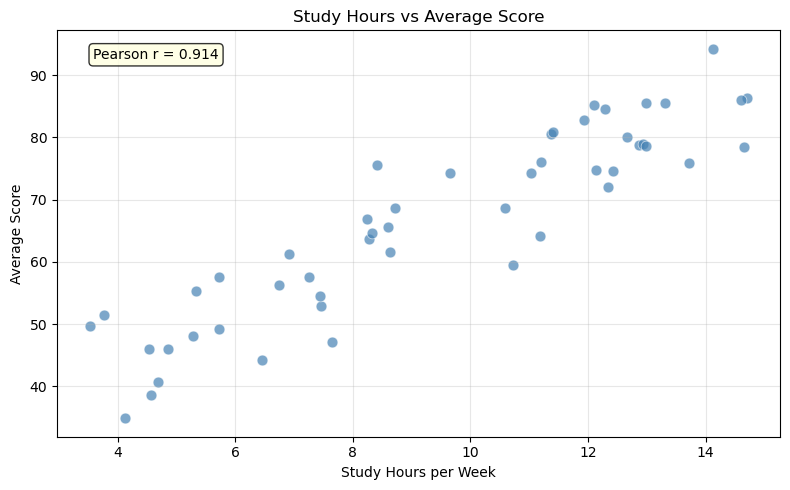

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(study_hours, avg_score, color='steelblue', s=60, alpha=0.7, edgecolors='white', linewidths=0.5)

r = np.corrcoef(study_hours, avg_score)[0, 1]
plt.text(0.05, 0.93, f'Pearson r = {r:.3f}', transform=plt.gca().transAxes,
         fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.title('Study Hours vs Average Score')
plt.xlabel('Study Hours per Week')
plt.ylabel('Average Score')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 2 : Color by category

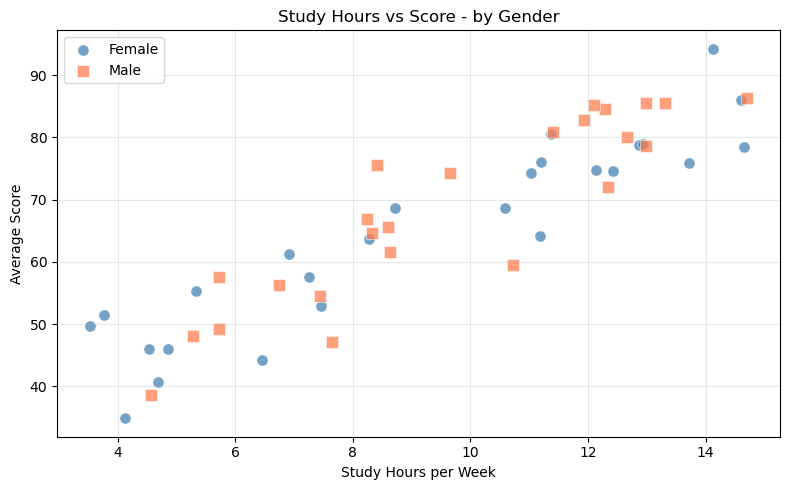

In [13]:
plt.figure(figsize=(8, 5))

for g, color, marker in [('Female', 'steelblue', 'o'), ('Male', 'coral', 's')]:
    mask = gender == g
    plt.scatter(study_hours[mask], avg_score[mask],
                color=color, marker=marker, s=65, alpha=0.75,
                edgecolors='white', linewidths=0.5, label=g)

plt.title('Study Hours vs Score - by Gender')
plt.xlabel('Study Hours per Week')
plt.ylabel('Average Score')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Plot 3 : Colormap scatter (attendance encodes color)

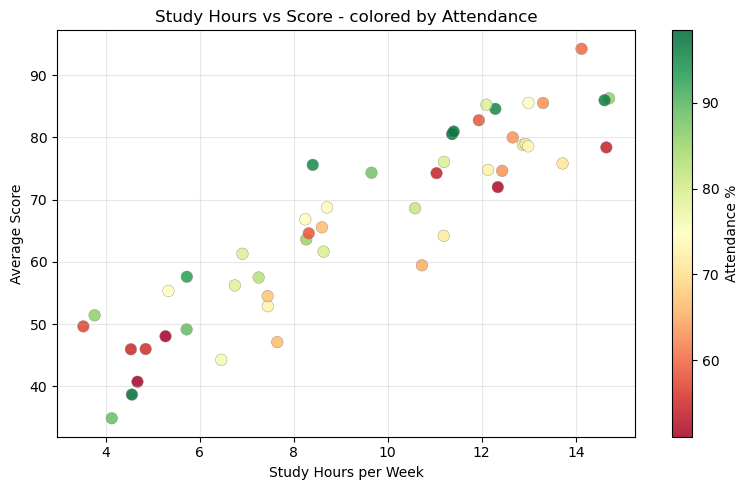

In [15]:
plt.figure(figsize=(8, 5))

sc = plt.scatter(study_hours, avg_score, c=attendance,
                 cmap='RdYlGn', s=70, alpha=0.85,
                 edgecolors='gray', linewidths=0.3)
plt.colorbar(sc, label='Attendance %')

plt.title('Study Hours vs Score - colored by Attendance')
plt.xlabel('Study Hours per Week')
plt.ylabel('Average Score')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 4 : Bubble chart 

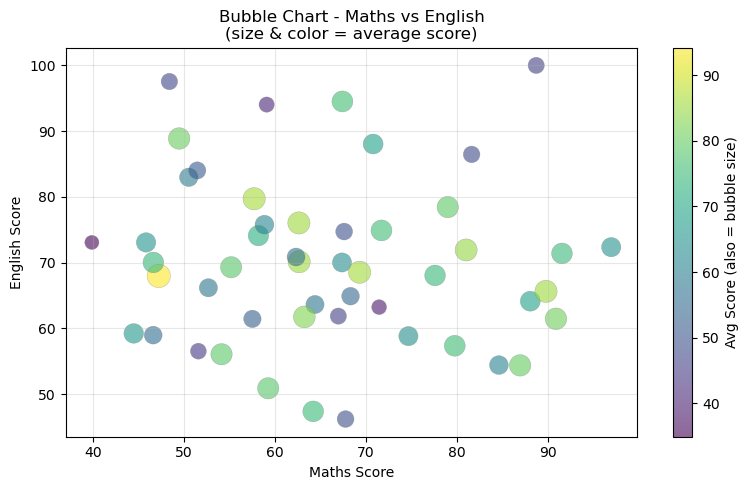

In [16]:
plt.figure(figsize=(8, 5))

sc2 = plt.scatter(maths, english, s=avg_score * 3,
                  c=avg_score, cmap='viridis',
                  alpha=0.6, edgecolors='gray', linewidths=0.3)
plt.colorbar(sc2, label='Avg Score (also = bubble size)')

plt.title('Bubble Chart - Maths vs English\n(size & color = average score)')
plt.xlabel('Maths Score')
plt.ylabel('English Score')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()